#### `Import Libraries`

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import cv2
import rasterio
import imageio
import tifffile as tiff
from PIL import Image
import os
from collections import Counter
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, models,Model,callbacks,optimizers,Input
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.preprocessing import image
from sklearn.metrics import precision_score, recall_score, f1_score,jaccard_score

#### `Read Data`

In [2]:
images_dir = "data\images"
masks_dir = "data\masks"

In [42]:
folders = {
    "Images Folder": "data\images",
    "Masks Folder": "data\masks"}

for name, path in folders.items():
    if os.path.exists(path):
        files_count = len([f for f in os.listdir(path) if os.path.isfile(os.path.join(path, f))])
        print(f"✅ {name}: contains {files_count} image")
    else:
        print(f"❌ {name}: folder not found")

✅ Images Folder: contains 306 image
✅ Masks Folder: contains 456 image


In [43]:
images = set(
    os.path.splitext(f)[0]
    for f in os.listdir(images_dir)
    if os.path.isfile(os.path.join(images_dir, f))
)

deleted = 0

for mask in os.listdir(masks_dir):
    mask_path = os.path.join(masks_dir, mask)

    if not os.path.isfile(mask_path):
        continue

    mask_id = os.path.splitext(mask)[0]

    if mask_id not in images:
        os.remove(mask_path)
        deleted += 1
        print(f"Deleted: {mask}")

print(f"\nDone ✅ | Total deleted masks: {deleted}")

Deleted: 100_184.png
Deleted: 101_89.png
Deleted: 102_179.png
Deleted: 103_225.png
Deleted: 104_20.png
Deleted: 105_148.png
Deleted: 106_267.png
Deleted: 107_59.png
Deleted: 108_236.png
Deleted: 109_223.png
Deleted: 10_244.png
Deleted: 110_287.png
Deleted: 111_121.png
Deleted: 112_78.png
Deleted: 113_44.png
Deleted: 114_220.png
Deleted: 115_49.png
Deleted: 116_250.png
Deleted: 117_97.png
Deleted: 118_125.png
Deleted: 119_222.png
Deleted: 11_116.png
Deleted: 120_305.png
Deleted: 121_142.png
Deleted: 122_257.png
Deleted: 123_145.png
Deleted: 124_95.png
Deleted: 125_201.png
Deleted: 126_110.png
Deleted: 127_54.png
Deleted: 128_294.png
Deleted: 129_177.png
Deleted: 12_286.png
Deleted: 130_256.png
Deleted: 131_185.png
Deleted: 132_126.png
Deleted: 133_224.png
Deleted: 134_153.png
Deleted: 135_56.png
Deleted: 136_301.png
Deleted: 137_140.png
Deleted: 138_39.png
Deleted: 139_108.png
Deleted: 13_234.png
Deleted: 140_34.png
Deleted: 141_237.png
Deleted: 142_238.png
Deleted: 143_183.png
Deleted:

#### `Understand Data Bands`

In [44]:
file_path = "data/images/6.tif"

with rasterio.open(file_path) as src:
    print(f"Total Bands: {src.count}")
    for i in range(1, src.count + 1):
        band = src.read(i)
        print(f"Band {i}: Shape {band.shape}, Min {band.min()}, Max {band.max()}")

Total Bands: 12
Band 1: Shape (128, 128), Min 132, Max 640
Band 2: Shape (128, 128), Min 122, Max 1199
Band 3: Shape (128, 128), Min 212, Max 1507
Band 4: Shape (128, 128), Min 141, Max 1800
Band 5: Shape (128, 128), Min 397, Max 4870
Band 6: Shape (128, 128), Min 187, Max 3483
Band 7: Shape (128, 128), Min 99, Max 4118
Band 8: Shape (128, 128), Min 64, Max 192
Band 9: Shape (128, 128), Min 66, Max 492
Band 10: Shape (128, 128), Min 71, Max 523
Band 11: Shape (128, 128), Min 10, Max 80
Band 12: Shape (128, 128), Min 0, Max 79


c:\Users\moham\AppData\Local\Programs\Python\Python310\lib\site-packages\rasterio\__init__.py:368: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
image_path = "data\images\9.tif"

with rasterio.open(image_path) as src:
    img = src.read()   
    print("Shape:", img.shape)

Shape: (12, 128, 128)


#### `Visualization`

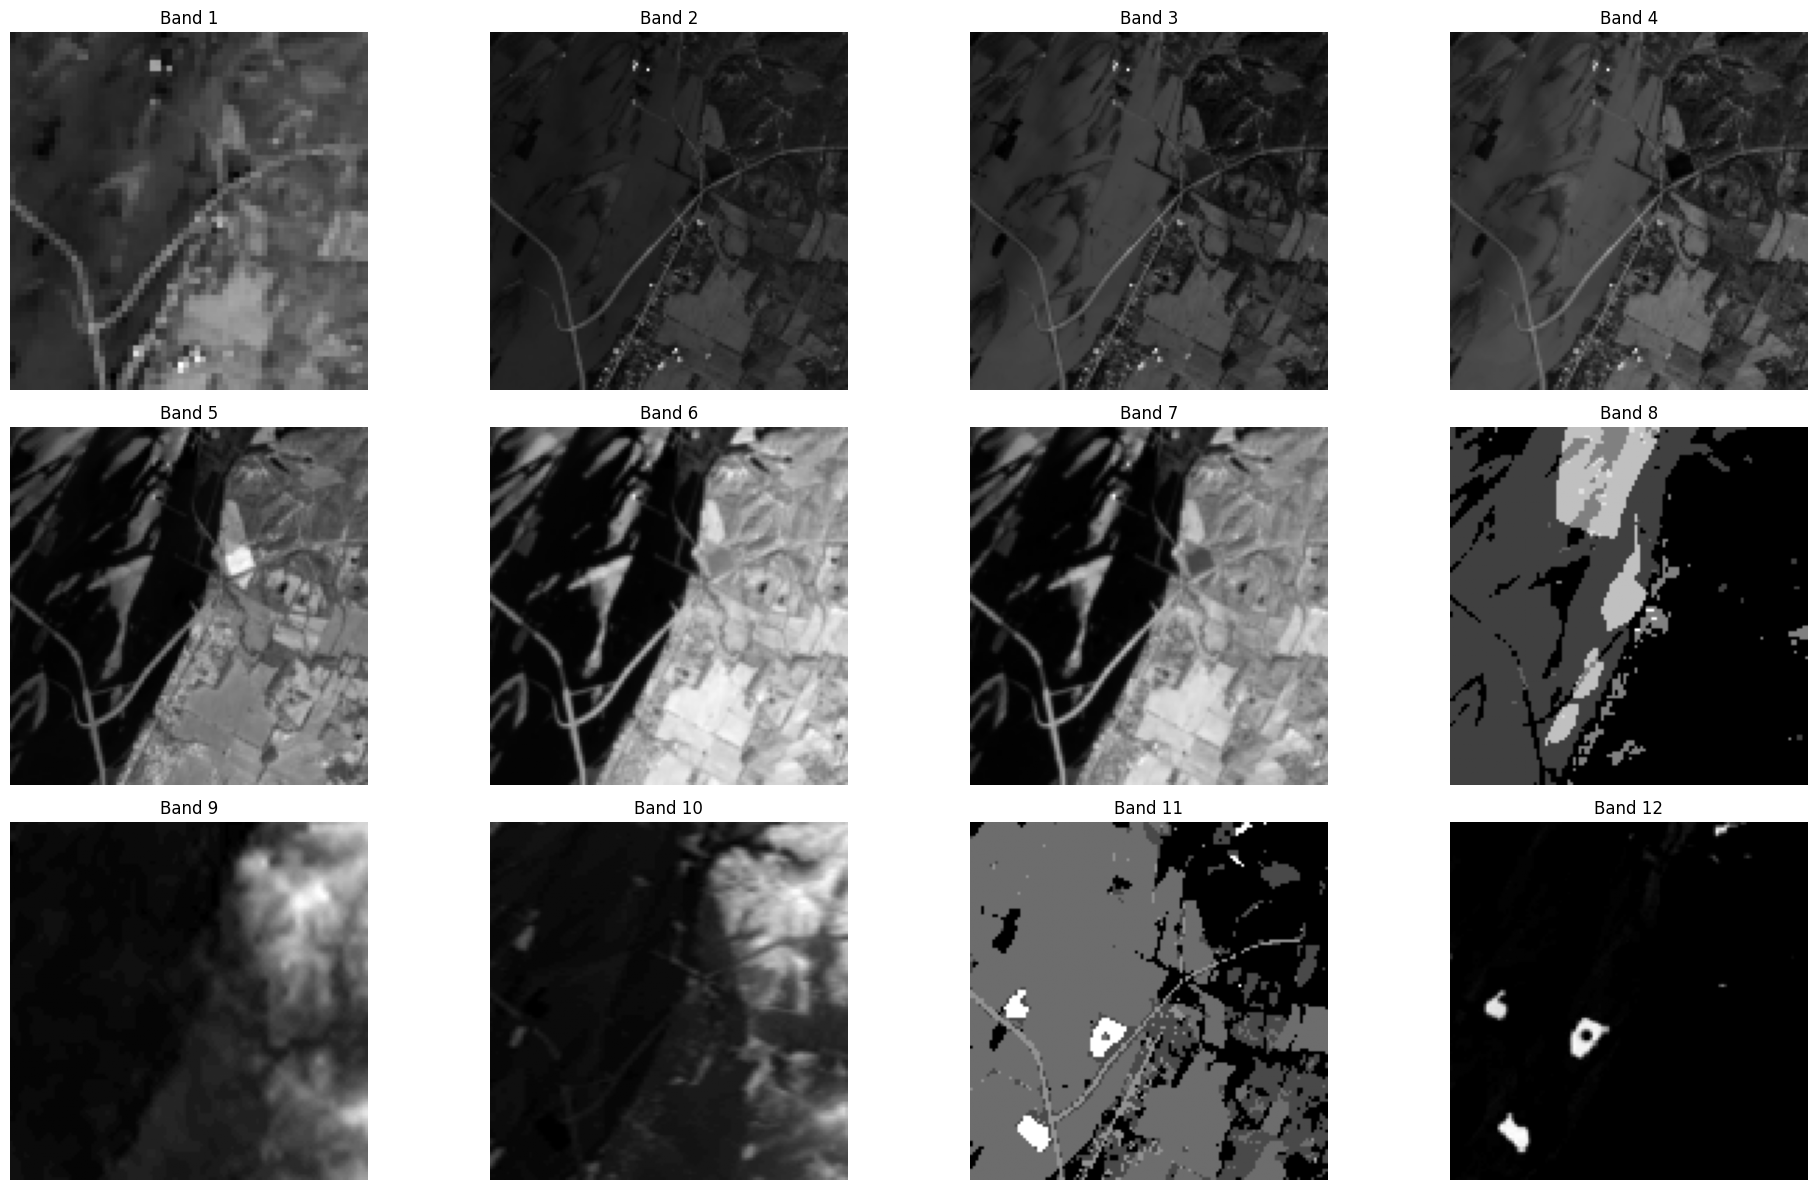

In [ ]:
num_bands = img.shape[0]

cols = 4
rows = int(np.ceil(num_bands / cols))

plt.figure(figsize=(20, 12))

for i in range(num_bands):
    plt.subplot(rows, cols, i+1)
    band = img[i]

    band = (band - band.min()) / (band.max() - band.min())

    plt.imshow(band, cmap='gray')
    plt.title(f'Band {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

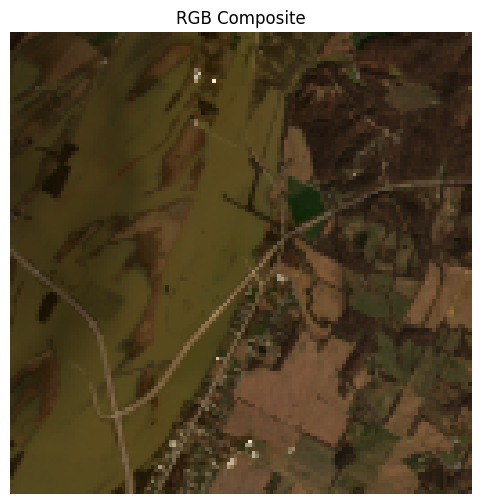

In [ ]:
red   = img[3]
green = img[2]
blue  = img[1]

rgb = np.stack([red, green, blue], axis=-1)

rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())

plt.figure(figsize=(6,6))
plt.imshow(rgb)
plt.title("RGB Composite")
plt.axis('off')
plt.show()

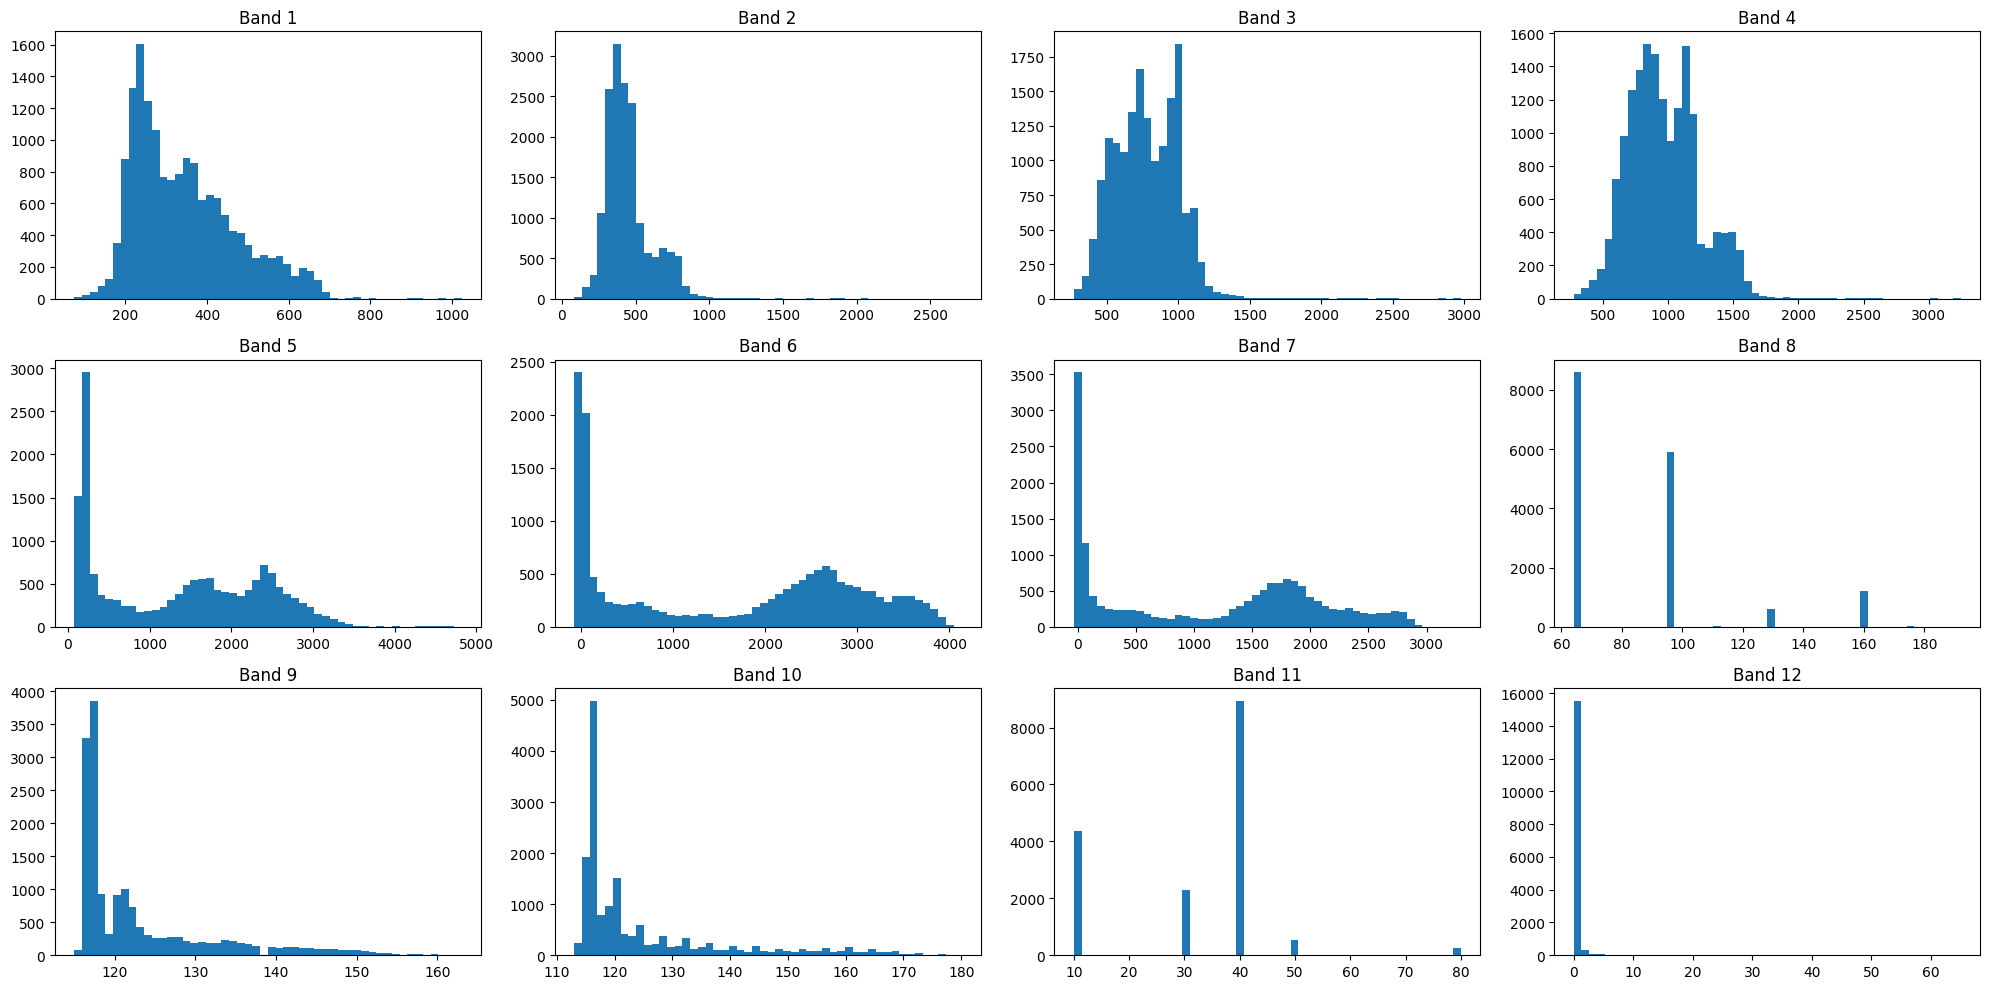

In [5]:
plt.figure(figsize=(20,10))

for i in range(num_bands):
    plt.subplot(3, 4, i+1)
    plt.hist(img[i].flatten(), bins=50)
    plt.title(f'Band {i+1}')
    
plt.tight_layout()
plt.show()

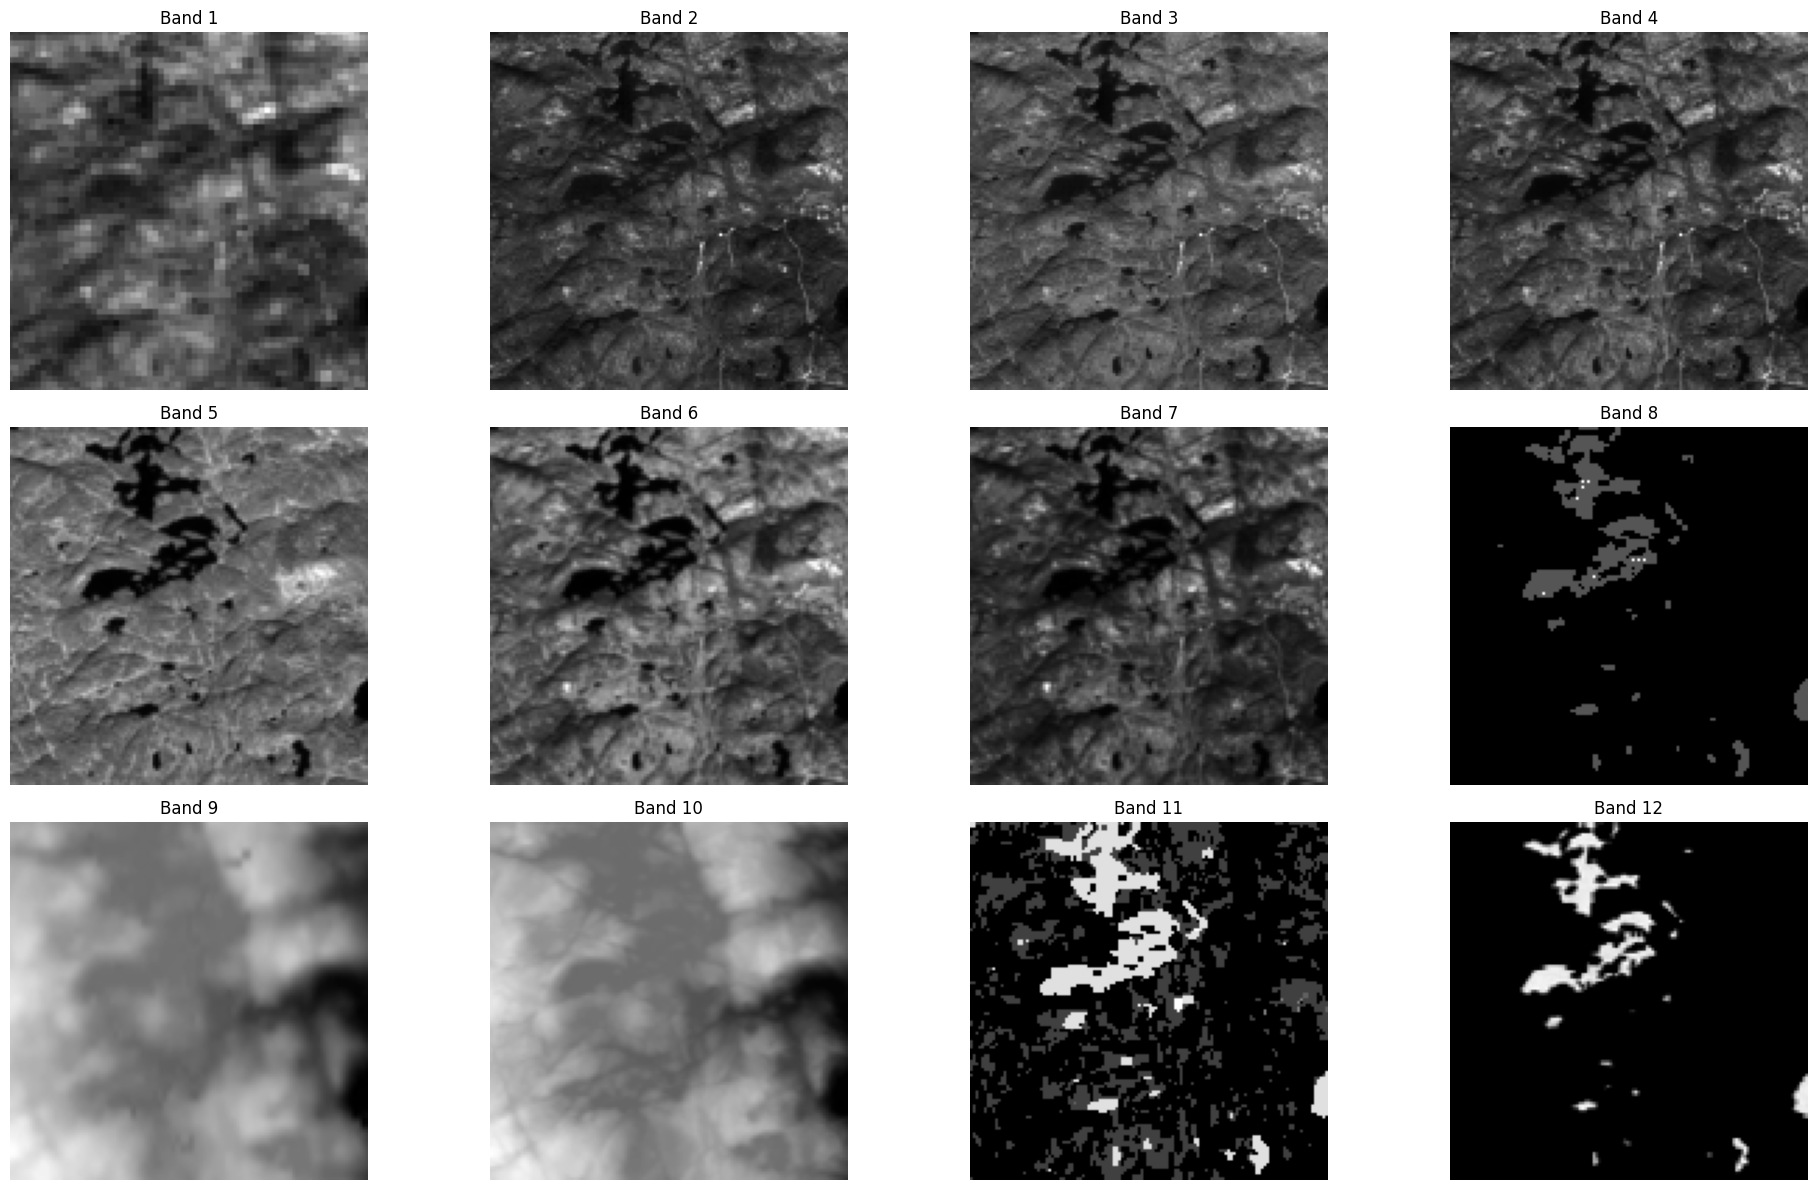

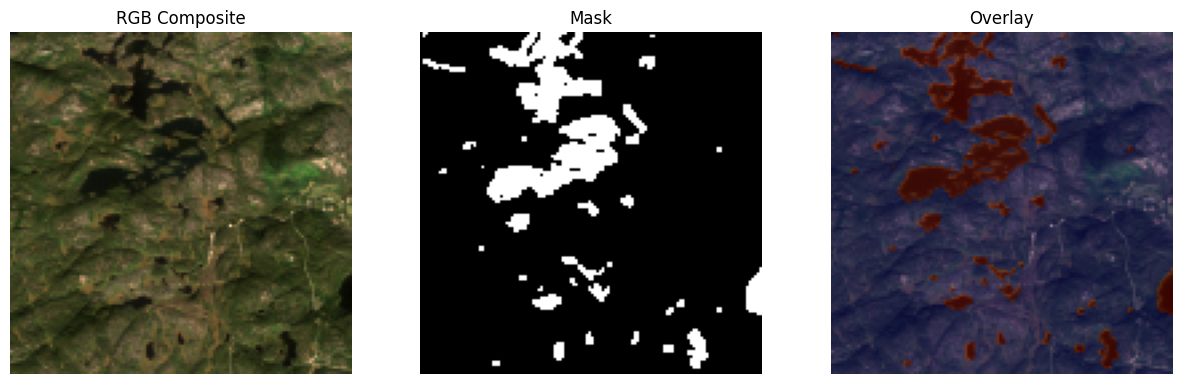

In [ ]:
image_path = "data/images/0.tif"
mask_path  = "data/masks/0.png"

with rasterio.open(image_path) as src:
    img = src.read()  # (12, H, W)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

num_bands = img.shape[0]

cols = 4
rows = int(np.ceil(num_bands / cols))

plt.figure(figsize=(20,12))
for i in range(num_bands):
    plt.subplot(rows, cols, i+1)
    
    band = img[i]
    band = (band - band.min()) / (band.max() - band.min() + 1e-6)
    
    plt.imshow(band, cmap='gray')
    plt.title(f'Band {i+1}')
    plt.axis('off')

plt.tight_layout()
plt.show()



red   = img[3]
green = img[2]
blue  = img[1]

rgb = np.stack([red, green, blue], axis=-1)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-6)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(rgb)
plt.title("RGB Composite")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(rgb)
plt.imshow(mask, cmap='jet', alpha=0.4)
plt.title("Overlay")
plt.axis('off')

plt.show()

#### `Load Data`

In [3]:
def load_data(image_dir, label_dir):
    images = []
    labels = []
    for filename in os.listdir(image_dir):
        base_name = filename.split('.')[0]
        image_path = os.path.join(image_dir, filename)
        label_path = os.path.join(label_dir, base_name + '.png')
        image = imageio.imread(image_path)
        label = imageio.imread(label_path)
        
        image = cv2.resize(image, (128, 128))
        label = cv2.resize(label, (128, 128))

        images.append(image)
        labels.append(label)

    return np.array(images), np.array(labels)

In [4]:
X,  Y = load_data(images_dir, masks_dir)
Y = np.expand_dims(Y, axis=-1)

C:\Users\moham\AppData\Local\Temp\ipykernel_10860\799626251.py:8: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(image_path)
C:\Users\moham\AppData\Local\Temp\ipykernel_10860\799626251.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  label = imageio.imread(label_path)


#### `Preprocessing`

#### `Normalization`

In [5]:
X = X.astype(np.float32)
X[:, :, :, [1, 2, 3]] /= 255.0  #  RGB bands
X[:, :, :, [i for i in range(12) if i not in [1, 2, 3]]] /= 10000.0  #  Rest of bands

#### `Split Data`

In [6]:
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
print("Train size:", len(X_train))
print("Val size:", len(X_val))
print("Train size:", len(Y_train))
print("Val size:", len(Y_val))

Train size: 244
Val size: 62
Train size: 244
Val size: 62


#### `Model`

In [7]:
def unet_model(input_shape=(128, 128, 12)):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(64, 3, activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D(2)(c1)
    
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(128, 3, activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D(2)(c2)
    
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(256, 3, activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D(2)(c3)
    
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(512, 3, activation='relu', padding='same')(c4)
    p4 = layers.MaxPooling2D(2)(c4)
     # Bottleneck
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(p4)
    c5 = layers.Conv2D(1024, 3, activation='relu', padding='same')(c5)
    
    # Decoder
    u6 = layers.Conv2DTranspose(512, 2, strides=2, activation='relu', padding='same')(c5)
    u6 = layers.concatenate([u6, c4])
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(512, 3, activation='relu', padding='same')(c6)
    
    u7 = layers.Conv2DTranspose(256, 2, strides=2, activation='relu', padding='same')(c6)
    u7 = layers.concatenate([u7, c3])
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(256, 3, activation='relu', padding='same')(c7)
    
    u8 = layers.Conv2DTranspose(128, 2, strides=2, activation='relu', padding='same')(c7)
    u8 = layers.concatenate([u8, c2])
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(u8)
    c8 = layers.Conv2D(128, 3, activation='relu', padding='same')(c8)
    
    u9 = layers.Conv2DTranspose(64, 2, strides=2, activation='relu', padding='same')(c8)
    u9 = layers.concatenate([u9, c1])
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(u9)
    c9 = layers.Conv2D(64, 3, activation='relu', padding='same')(c9)
    
    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

In [5]:
model = unet_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      6,976 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_2[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_4[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_2[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │  2,359,808 │ conv2d_6[0][0]    │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 8, 8, 512) │          0 │ conv2d_7[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 8, 8,      │  4,719,616 │ max_pooling2d_3[… │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 8, 8,      │  9,438,208 │ conv2d_8[0][0]    │
│                     │ 1024)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 16, 16,    │  2,097,664 │ conv2d_9[0][0]    │
│ (Conv2DTranspose)   │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 16, 16,    │          0 │ conv2d_transpose

 Total params: 31,036,929 (118.40 MB)

 Trainable params: 31,036,929 (118.40 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
CALLBACKS = [
    ModelCheckpoint('/kaggle/working/unet.keras', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

In [29]:
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    batch_size=16,
    epochs=20,
    callbacks=CALLBACKS
)

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 125s 7s/step - accuracy: 0.8035 - loss: 0.4328 - val_accuracy: 0.9013 - val_loss: 0.3377
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 100s 6s/step - accuracy: 0.8872 - loss: 0.3598 - val_accuracy: 0.9047 - val_loss: 0.2866
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 99s 6s/step - accuracy: 0.8903 - loss: 0.3138 - val_accuracy: 0.9034 - val_loss: 0.2834
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 105s 7s/step - accuracy: 0.8857 - loss: 0.3174 - val_accuracy: 0.9067 - val_loss: 0.2678
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 100s 6s/step - accuracy: 0.8972 - loss: 0.3081 - val_accuracy: 0.9111 - val_loss: 0.2785
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 98s 6s/step - accuracy: 0.9071 - loss: 0.2769 - val_accuracy: 0.9142 - val_loss: 0.2499
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 98s 6s/step - accuracy: 0.9102 - loss: 0.2640 - val_accuracy: 0.9163 - val_loss: 0.2307
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 0.9039 - loss: 0.2663 - val_accuracy: 0.9186 - val_l

In [39]:
train_loss, train_acc = model.evaluate(X_train,Y_train)
print(f"Train Accuracy: {train_acc:.4f}")

val_loss, val_acc = model.evaluate(X_val,Y_val)
print(f"Val Accuracy: {val_acc:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.9062 - loss: 0.2253
Train Accuracy: 0.9111
2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.9192 - loss: 0.1993
Val Accuracy: 0.9207


In [30]:
def evaluate_model(y_true, y_pred):
    y_true_flat = y_true.flatten()
    y_pred_flat = (y_pred.flatten() > 0.5).astype(np.uint8)

    precision = precision_score(y_true_flat, y_pred_flat)
    recall = recall_score(y_true_flat, y_pred_flat)
    f1 = f1_score(y_true_flat, y_pred_flat)
    iou = jaccard_score(y_true_flat, y_pred_flat)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"IoU: {iou:.4f}")

In [33]:
y_pred = model.predict(X_val)
evaluate_model(Y_val, y_pred)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step
Precision: 0.9280
Recall: 0.7008
F1-Score: 0.7986
IoU: 0.6647


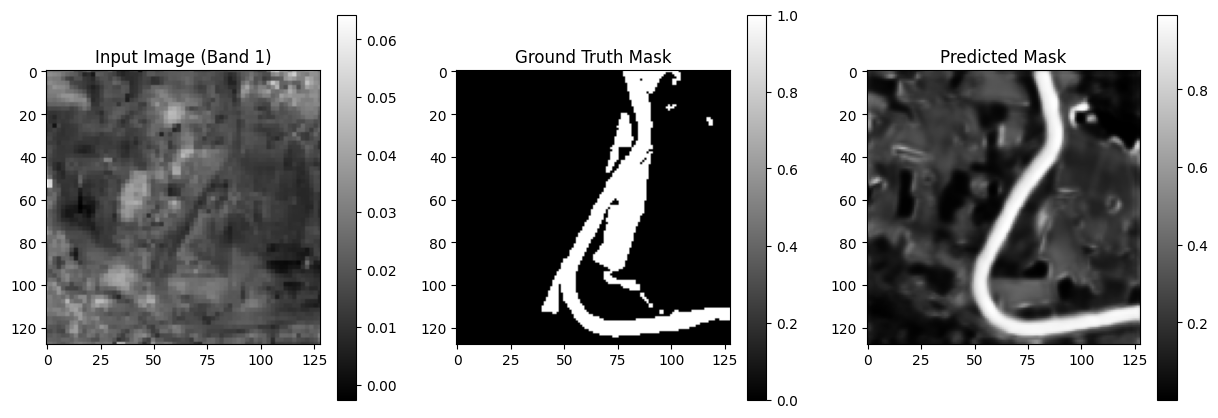

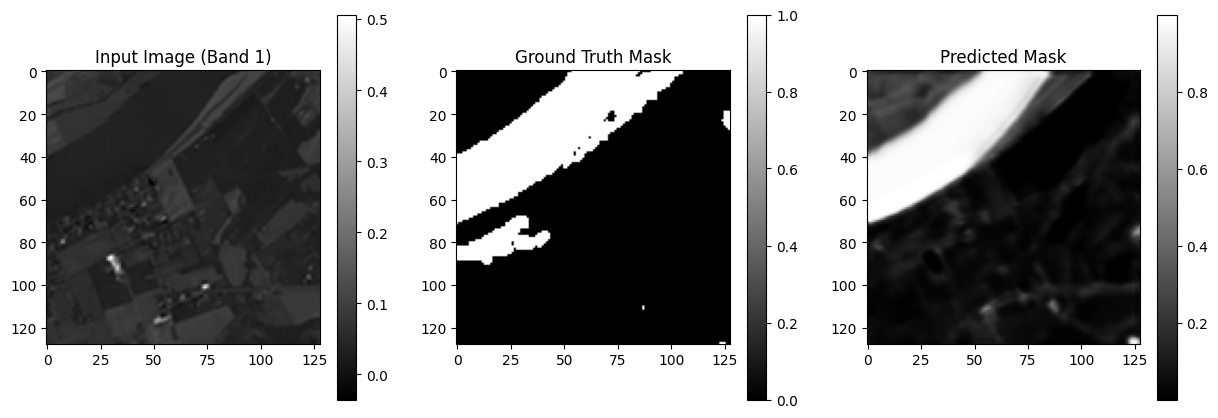

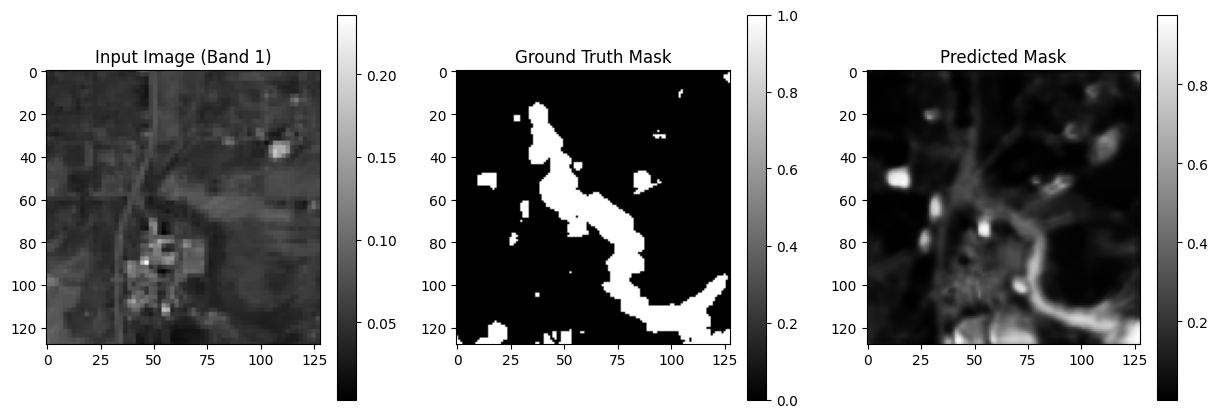

In [34]:
num_visualizations = 3
for i in range(num_visualizations):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title('Input Image (Band 1)')
    plt.imshow(X_val[i, :, :, 0], cmap='gray')
    plt.colorbar()

    plt.subplot(1, 3, 2)
    plt.title('Ground Truth Mask')
    plt.imshow(Y_val[i, :, :, 0], cmap='gray')
    plt.colorbar()

    plt.subplot(1, 3, 3)
    plt.title('Predicted Mask')
    plt.imshow(y_pred[i, :, :, 0], cmap='gray')
    plt.colorbar()

    plt.show()